## Plan of the module 2:

1. Deutsch (D) algorithm overview
2. Deutsch algorithm - implementation using quantum composer
3. Deutsch-Jozsa(DJ) algorithm and it's implementation using quantum composer
4. Implementation of D and DJ alghoritms with Qiskit code
5. Direct evaluation of oracle functions without D and DJ alghoritms
6. Homework

# I. Deutsch algorithm
* Theoretical explanation and proof.
* implementation in quantum composer and Qiskit.

##  I.1. Excercise:
1. Create quantum circuits coresponding to oracles representing function f: $\{0,1\}\to\{0,1\}$ which is either constatnt or balanced (4 different possibilities) e.g.:\
   $f_1(0)=0, \;  f_1(1)=0$;\
   $f_2(0)=1, \;  f_2(1)=1$;\
   $f_3(0)=0, \;  f_3(1)=1$;\
   $f_4(0)=1, \;  f_4(1)=0$
3. Create a ciruit which checks clasically (directly) if the function is constat or balanced
4. Implement Deutch alghoritm for each of the oracle
5. Reaize above tasks:
    * using quantum composer (optionally)
    * qiskit and perfect noisless simulator (e.g. using ```StatevectorSampler``` class)
    * qiskit and one of the noisy simulators (fake providers https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider using one of the fake providers e.g.: ```FakeFez```, ```FakeTorino```,  ```FakeKyiv```,  ```FakeSherbrooke```,  ```FakeBrisbane```)


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv

#EXERCISE 1.1
def deutsch_function(case: int): #Function, that creates f,  implemented in cells below


    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

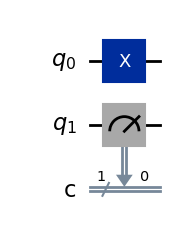

Noiseless: {'0': 1024}
Noisy: {'0': 1022, '1': 2}


In [2]:
#EXERCISE 1.2

case = 1 #which f(x) we apply

# -----------------------
# NOISELESS VERSION
# -----------------------

qc_ideal = QuantumCircuit(2, 1)

# Manually choose the input, we have to check both f(0) and f(1) in this classical approach
qc_ideal.x(0)   # x = 1
# lack of qc_ideal.x(0) means x = 0

qc_ideal.compose(deutsch_function(case), inplace=True)

qc_ideal.measure(1, 0)

display(qc_ideal.draw("mpl"))

sampler_ideal = StatevectorSampler()
job_ideal = sampler_ideal.run([qc_ideal], shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal[0].data.c.get_counts()

print("Noiseless:", counts_ideal)


# NOISY 

qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)


sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

# We obtain f(x) for a manually chosen input x.
# To determine if the function is constant or balanced,
# we must check both x = 0 and x = 1 separately. 

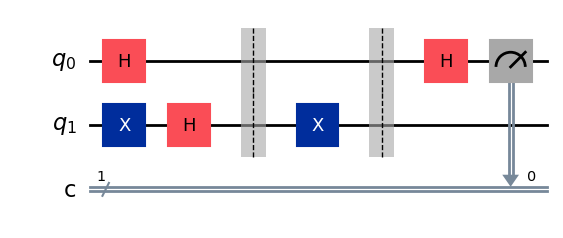

Noiseless: {'0': 1024}
Noiseless result: constant
Noisy: {'0': 1021, '1': 3}
Noisy result: constant


In [3]:
#EXCERCISE 1.3 - Deutch algorithm in quantum approach

case = 4
deutsch_func = deutsch_function(case)


# NOISELESS VERSION

qc_ideal = QuantumCircuit(2, 1)

qc_ideal.x(1)
qc_ideal.h(0)
qc_ideal.h(1)

qc_ideal.barrier()
qc_ideal.compose(deutsch_func, inplace=True)
qc_ideal.barrier()

qc_ideal.h(0)
qc_ideal.measure(0, 0)

display(qc_ideal.draw("mpl"))

sampler_ideal = StatevectorSampler()
job_ideal = sampler_ideal.run([qc_ideal], shots=1024)
result_ideal = job_ideal.result()
counts_ideal = result_ideal[0].data.c.get_counts()

print("Noiseless:", counts_ideal)

if counts_ideal.get("0", 0) > counts_ideal.get("1", 0):
    print("Noiseless result: constant")
else:
    print("Noiseless result: balanced")


# NOISY VERSION

qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)


sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)
result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

if counts_noisy.get("0", 0) > counts_noisy.get("1", 0):
    print("Noisy result: constant")
else:
    print("Noisy result: balanced")

# II Deutsch-Jozsa algorithm
* Theoretical explanation and proof.
* implementation in quantum composer and Qiskit.

For a two-qubit system, there are 16 possible boolean functions $f: \{0,1\}^2\to\{0,1\}$. Each of these functions assigns an output of 0 or 1 to each of the four possible inpot states (computational basis states: $|00\rangle$, $|01\rangle$, $|10\rangle$, and $|11\rangle$).

Below, we will use the IBM Quantum Composer and Qiskit code to implement the Deutsch-Jozsa algorithm to evaluate various oracle functions.

Let's implement the Deutsch-Jozsa algorithm for a specific function that assigns 0, 1, 1, and 0 to each of the possible two-bit input sequences (00, 01, 10, and 11, respectively):\
$f(00)=0$\
$f(01)=1$\
$f(10)=1$\
$f(11)=0$

This is the addition modulo 2 function, also known as the XOR function, where $f(a,b)=a\oplus b$.

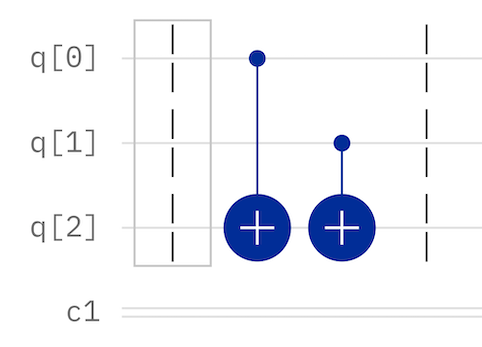
## $a=q[1]$, $b=q[0]$

## Exercise 2.1
* Implement the circuit described above using the Quantum Composer.
* Analyze the results of running this circuit to verify that the oracle function is balanced.
* Prove that applying the two CNOT gates successfully achieves the addition modulo 2 operation, where $f(a,b)=a\oplus b$.

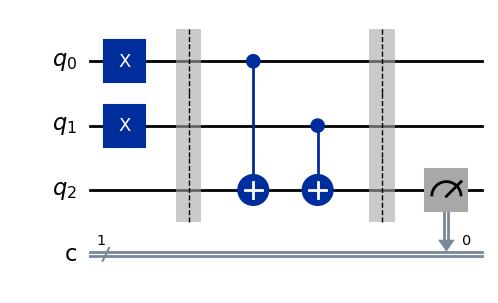

{'0': 1024}


In [5]:
# DEUTSCH–JOZSA algorithm - EXERCISE 2

qc = QuantumCircuit(3, 1)  # we have 3 qubits: x0, x1 (inputs) and one output qubit

qc.x(0)  # manually set x0 = 1 
qc.x(1)  # manually set x1 = 1 

qc.barrier()
qc.cx(0, 2)
qc.cx(1, 2)
qc.barrier()

qc.measure(2, 0) 

display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)  

## Exercise 2.2: 
Using Qiskit, program a quantum circuit that implements the Deutsch-Jozsa algorithm for the balanced oracle $f(a,b)=a\oplus b$ (addition modulo 2).

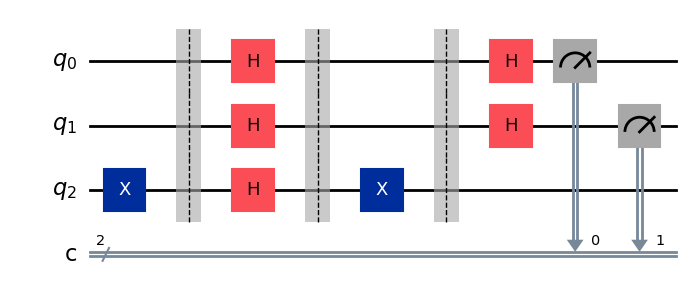

Noiseless: {'00': 1024}
Noiseless result: constant
Noisy: {'00': 1021, '10': 1, '01': 2}
Noisy result: constant


In [11]:
#Deutsh jozsa algorithm for 2-bit input - EXCERCISE 2.2

# NOISELESS VERSION


qc_ideal = QuantumCircuit(3, 2)

qc_ideal.x(2)

qc_ideal.barrier()
qc_ideal.h(0)
qc_ideal.h(1)
qc_ideal.h(2)

qc_ideal.barrier()
qc_ideal.x(2)
qc_ideal.barrier()

qc_ideal.h(0)
qc_ideal.h(1)

qc_ideal.measure(0, 0)
qc_ideal.measure(1, 1)

display(qc_ideal.draw("mpl"))

sim = Aer.get_backend("aer_simulator")
qc_compiled = transpile(qc_ideal, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts_ideal = result.get_counts()

print("Noiseless:", counts_ideal)

most_likely_ideal = max(counts_ideal, key=counts_ideal.get)

if most_likely_ideal == "00":
    print("Noiseless result: constant")
else:
    print("Noiseless result: balanced")


# NOISY VERSION


qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)

sampler_noisy = SamplerV2(backend)
job_noisy = sampler_noisy.run([qc_transpiled], shots=1024)

result_noisy = job_noisy.result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

most_likely_noisy = max(counts_noisy, key=counts_noisy.get)

if most_likely_noisy == "00":
    print("Noisy result: constant")
else:
    print("Noisy result: balanced")

## Exercise 2.3: 

Construct a Deutsch-Jozsa circuit that implements the two possible constant oracles. For any 2-qubit input state $x \in \{00, 01, 10, 11\}$, the functions evaluate as follows:$f_0(x) = 0$ (The all-zeros function) and $f_1(x) = 1$ (The all-ones function)

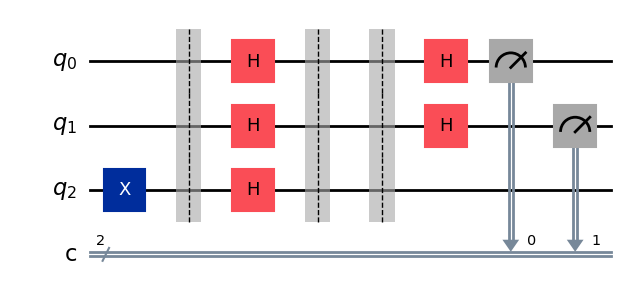

Noiseless: {'00': 1024}
Noiseless result: constant
Noisy: {'00': 1023, '10': 1}
Noisy result: constant


In [12]:
#Deutsh jozsa algorithm for 2-bit input - EXCERCISE 2.3 - all zeros

# NOISELESS VERSION


qc_ideal = QuantumCircuit(3, 2)

qc_ideal.x(2)

qc_ideal.barrier()
qc_ideal.h(0)
qc_ideal.h(1)
qc_ideal.h(2)

qc_ideal.barrier()

# oracle: f(x)=0
# no operation

qc_ideal.barrier()

qc_ideal.h(0)
qc_ideal.h(1)

qc_ideal.measure(0,0)
qc_ideal.measure(1,1)

display(qc_ideal.draw("mpl"))

sim = Aer.get_backend("aer_simulator")

qc_compiled = transpile(qc_ideal, sim)

job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts_ideal = result.get_counts()

print("Noiseless:", counts_ideal)

most_likely_ideal = max(counts_ideal, key=counts_ideal.get)

if most_likely_ideal == "00":
    print("Noiseless result: constant")
else:
    print("Noiseless result: balanced")



# NOISY VERSION


qc_noisy = qc_ideal.copy()

backend = FakeKyiv()

qc_transpiled = transpile(qc_noisy, backend)

sampler_noisy = SamplerV2(backend)

job_noisy = sampler_noisy.run(
    [qc_transpiled],
    shots=1024
)

result_noisy = job_noisy.result()

counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

most_likely_noisy = max(counts_noisy, key=counts_noisy.get)

if most_likely_noisy == "00":
    print("Noisy result: constant")
else:
    print("Noisy result: balanced")

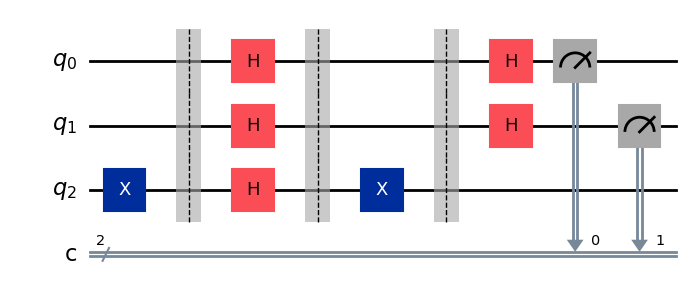

{'00': 1024}
constant
Noisy: {'00': 1022, '10': 1, '01': 1}
Noisy result: constant


In [13]:
#Deutsh jozsa algorithm for 2-bit input - EXCERCISE 2.3 - all ones
qc = QuantumCircuit(3, 2) 
qc.x(2)

qc.barrier()
qc.h(0)
qc.h(1)
qc.h(2)


qc.barrier()
qc.x(2)
qc.barrier()

qc.h(0)
qc.h(1)

qc.measure(0,0)
qc.measure(1,1)
display(qc.draw('mpl'))

sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)
most_likely = max(counts, key=counts.get)

if most_likely == "00":
    print("constant")
else:
    print("balanced")


## Exercise 2.4:
Following tutorial (https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm (see ```dj_query(num_qubits)``` function for details) implement some quantum cricuit coresponding to oracles representing function f: $\{0,1\}^3\to\{0,1\}$ which is either constatnt or balanced 

In [15]:
#EXCERCISE 2.4
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc


def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc



def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

## Exercise 2.4
Following the IBM Quantum tutorial on the Deutsch-Jozsa algorithm (https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm) as a guide, implement a one of possible quantum circuits for a 3-qubit oracle. Your circuit should correspond to a function $f: \{0,1\}^3\to\{0,1\}$ that is strictly either constant or balanced. (Hint: See the ```dj_query(num_qubits)``` function in the tutorial for implementation details).

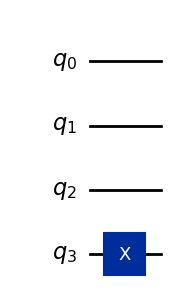

Noiseless: {'000': 1024}
Noisy: {'000': 1020, '100': 1, '010': 3}
Algorithm result: constant


In [16]:
#EXCERCISE 2.4 and 2.4v2

from qiskit import transpile
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeKyiv

f = dj_query(3)
display(f.draw("mpl"))

qc = compile_circuit(f)

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()

print("Noiseless:", counts)

backend = FakeKyiv()
qc_noisy = transpile(qc, backend)

sampler_noisy = SamplerV2(backend)
result_noisy = sampler_noisy.run([qc_noisy], shots=1024).result()
counts_noisy = result_noisy[0].data.c.get_counts()

print("Noisy:", counts_noisy)

print("Algorithm result:", dj_algorithm(f))

## Exercise 2.5:
Execute all the Deutsch-Jozsa circuits defined above on both an ideal (noiseless) simulator and a noisy simulator (e.g. using ```FakeKyiv```,  ```FakeSherbrooke```, ```FakeBrisbane``` or some other backend with more than 100 qubits).

1. Use the quantum simulation results to verify if each oracle is balanced or constant.

2. Test the oracles directly to confirm that their classical behavior corresponds correctly to constant or balanced functions.

# Homework 1
Finish excersies from today's labs

# Homework 2

Get familiar with announcements from one of the Quantum Summits: https://newsroom.ibm.com/2022-11-09-IBM-Unveils-400-Qubit-Plus-Quantum-Processor-and-Next-Generation-IBM-Quantum-System-Two

CNOT gate:
https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CXGate